Варіант 6

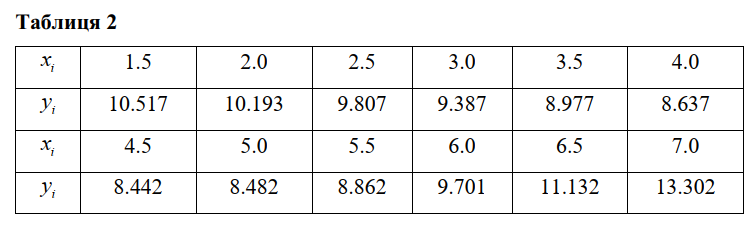

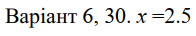

In [ ]:
import numpy as np

# Таблиця значень функції
x_values = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])
y_values = np.array([10.517, 10.193, 9.807, 9.387, 8.977, 8.637, 8.442, 8.482, 8.862, 9.701, 11.132, 13.302])

# Крок таблиці
h = x_values[1] - x_values[0]

# Обчислення кінцевих різниць
def finite_differences(y):
  n = len(y)
  delta_y = np.zeros((n, n))
  delta_y[:, 0] = y

  for j in range(1, n):
    for i in range(n - j):
      delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]

  return delta_y
# Отримуємо таблицю кінцевих різниць
delta_table = finite_differences(y_values)

# Виводимо таблицю кінцевих різниць для наочності
print("Таблиця кінцевих різниць:")
np.set_printoptions(precision=4, suppress=True)
print(delta_table)

# Значення кінцевих різниць для першої та другої похідних
delta_y1 = delta_table[2, 1] # Δy
delta2_y1 = delta_table[2, 2] # Δ²y
delta3_y1 = delta_table[2, 3] # Δ³y
delta4_y1 = delta_table[2, 4] # Δ⁴y

# Функція для обчислення першої похідної за формулою Ньютона
def first_derivative(delta_y1, delta2_y1, delta3_y1, delta4_y1,h):
  return (delta_y1 - delta2_y1 / 2 + delta3_y1 / 3 - delta4_y1 / 4) / h

# Функція для обчислення другої похідної за формулою Ньютона
def second_derivative(delta2_y1, delta3_y1, delta4_y1, h):
  return (delta2_y1 - delta3_y1 + 11*delta4_y1 / 12) / h**2

# Обчислюємо першу та другу похідні
y1_prime = first_derivative(delta_y1, delta2_y1, delta3_y1, delta4_y1, h)
y1_double_prime = second_derivative(delta2_y1, delta3_y1, delta4_y1, h)

y1_prime = round(y1_prime, 3)
y1_double_prime = round(y1_double_prime, 3)

# Виводимо результати
print(f"\nПерша похідна y'(2.5) ≈ {y1_prime}")
print(f"Друга похідна y''(2.5) ≈ {y1_double_prime}")

Таблиця кінцевих різниць:
[[10.517 -0.324 -0.062  0.028  0.016 -0.    -0.001  0.002 -0.003  0.003
   0.    -0.009]
 [10.193 -0.386 -0.034  0.044  0.016 -0.001  0.001 -0.001 -0.     0.003
  -0.009  0.   ]
 [ 9.807 -0.42   0.01   0.06   0.015  0.     0.    -0.001  0.003 -0.006
   0.     0.   ]
 [ 9.387 -0.41   0.07   0.075  0.015  0.    -0.001  0.002 -0.003  0.
   0.     0.   ]
 [ 8.977 -0.34   0.145  0.09   0.015 -0.001  0.001 -0.001  0.     0.
   0.     0.   ]
 [ 8.637 -0.195  0.235  0.105  0.014  0.    -0.     0.     0.     0.
   0.     0.   ]
 [ 8.442  0.04   0.34   0.119  0.014  0.     0.     0.     0.     0.
   0.     0.   ]
 [ 8.482  0.38   0.459  0.133  0.014  0.     0.     0.     0.     0.
   0.     0.   ]
 [ 8.862  0.839  0.592  0.147  0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [ 9.701  1.431  0.739  0.     0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [11.132  2.17   0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.   ]
 [13.302  0.     0.

In [ ]:
# Обчислення кінцевих різниць
# Перша похідна
first_derivative = (y_values[1:] - y_values[:-1]) / h
# Друга похідна
second_derivative = (first_derivative[1:] - first_derivative[:-1]) / h

# Виведення результатів
print("Перша похідна:")
print("x = 2.5:", round(first_derivative[2], 3))
print("Друга похідна:")
print("x = 2.5:", round(second_derivative[2], 3))

Перша похідна:
x = 2.5: -0.84
Друга похідна:
x = 2.5: 0.04


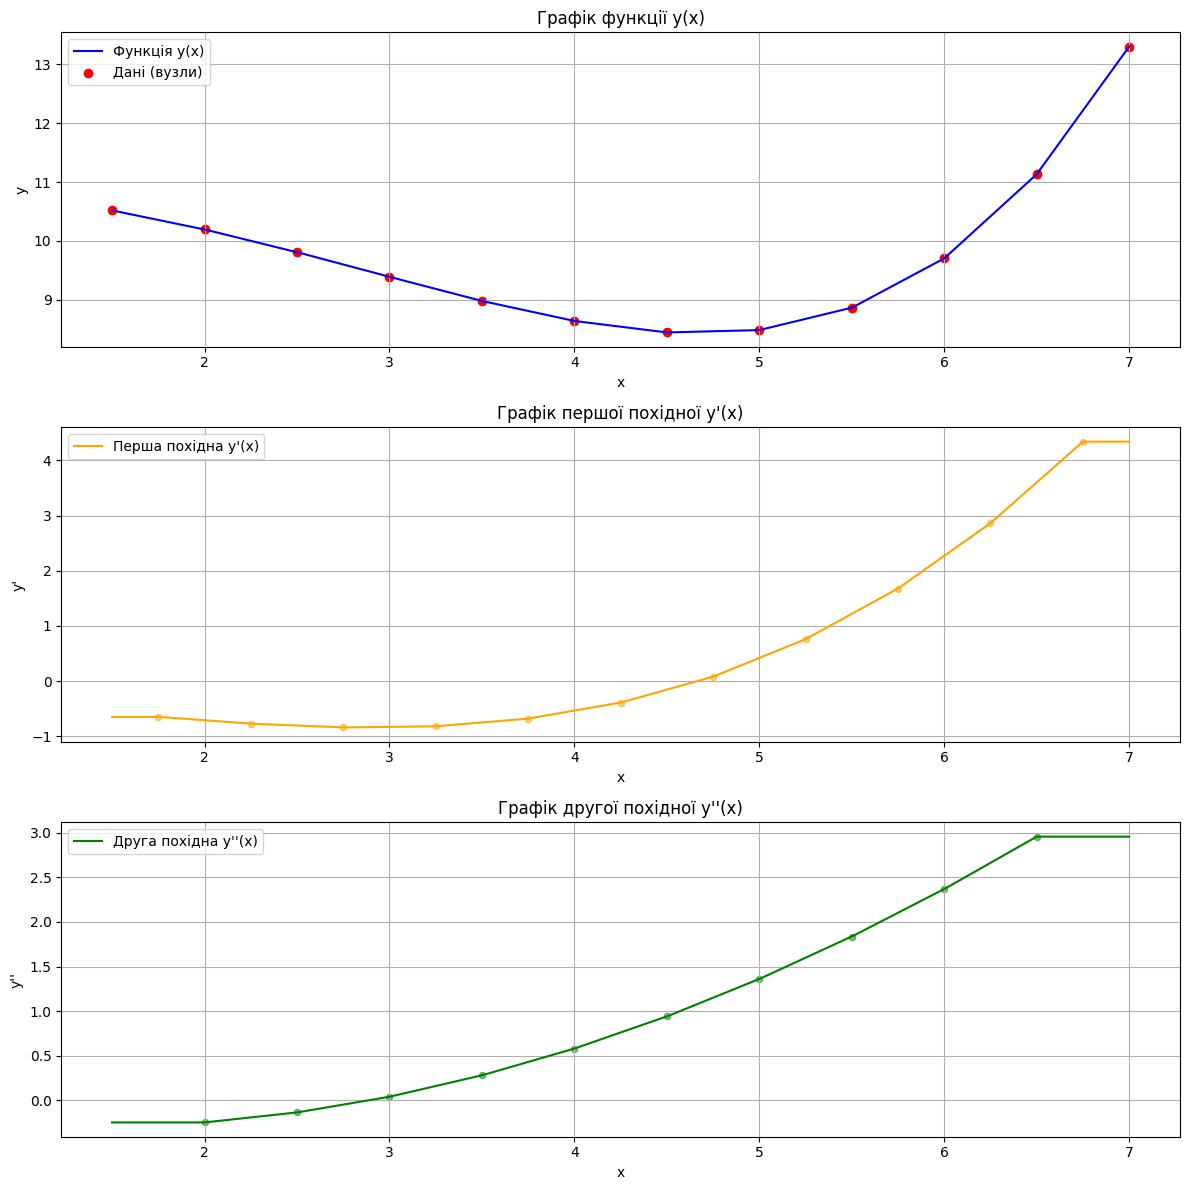

In [ ]:
import matplotlib.pyplot as plt

first_derivative = np.diff(y_values) / h
second_derivative = np.diff(first_derivative) / h

x_fine = np.linspace(x_values[0], x_values[-1], 500)
y_fine = np.interp(x_fine, x_values, y_values)

x_deriv1 = (x_values[:-1] + x_values[1:]) / 2
x_deriv2 = x_values[1:-1]

first_deriv_fine = np.interp(x_fine, x_deriv1, first_derivative)
second_deriv_fine = np.interp(x_fine, x_deriv2, second_derivative)

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1)
plt.plot(x_fine, y_fine, label='Функція y(x)', color='blue')
plt.scatter(x_values, y_values, color='red', label='Дані (вузли)') # Додав точки даних
plt.title('Графік функції y(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(x_fine, first_deriv_fine, label="Перша похідна y'(x)", color='orange')
plt.scatter(x_deriv1, first_derivative, color='orange', alpha=0.5, s=20)
plt.title("Графік першої похідної y'(x)")
plt.xlabel('x')
plt.ylabel("y'")
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(x_fine, second_deriv_fine, label="Друга похідна y''(x)", color='green')
plt.scatter(x_deriv2, second_derivative, color='green', alpha=0.5, s=20)
plt.title("Графік другої похідної y''(x)")
plt.xlabel('x')
plt.ylabel("y''")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()